# L16-17 RVs & Estimations & Bias & Variance

- Some contents are about stats and omitted

## Estimation

- Prediction: We care how accurate is $\hat{Y}$ with $X$, we don't really care the relations between them

- Inference: We care the relation between $Y$ and $X$, it is reflected by parameter $\beta$

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **e.g.**

- Population: **All heights** of people

- Real average height is $\mu=175.3$, this is **parameter (参数，总体参数)** and you don't know the exact number

- You cannot measure everyone in reality, so you pick 1000 people:

$$X_1, X_2, ..., X_{1000}$$

- You compute the sample average $\bar{X}=\frac{1}{1000} \Sigma{X_i} = 174.8$, this is **statistic (统计量，样本统计量)**

**Summary**

- Parameter is the feature of **population**, it is usually not changed and unknown

- Statistic is the feature of **sample** from population, it is known from sample and can change if you conduct another sampling
  
  - So **we can treat statistics as a RV of sample**, it depends on the actual realization of each sampling

---

- If we use $\bar{X}$ to estimate $\mu$, we call $\bar{X}$ an estimator of $\mu$

- We use $\theta$ to represent real parameter, $\hat{\theta}$ for its estimator

</div>

## Prediction as a Data-Generating Process

- Say we are working with an input $x$ and an output / response $Y$

- We assume a relation between them: $Y should\ be\ g(x)$

	- $g(\cdot)$ represents some "universal truth" or "law of nature", basically we just assume it is the true underlying relationship between $x$ & $Y$

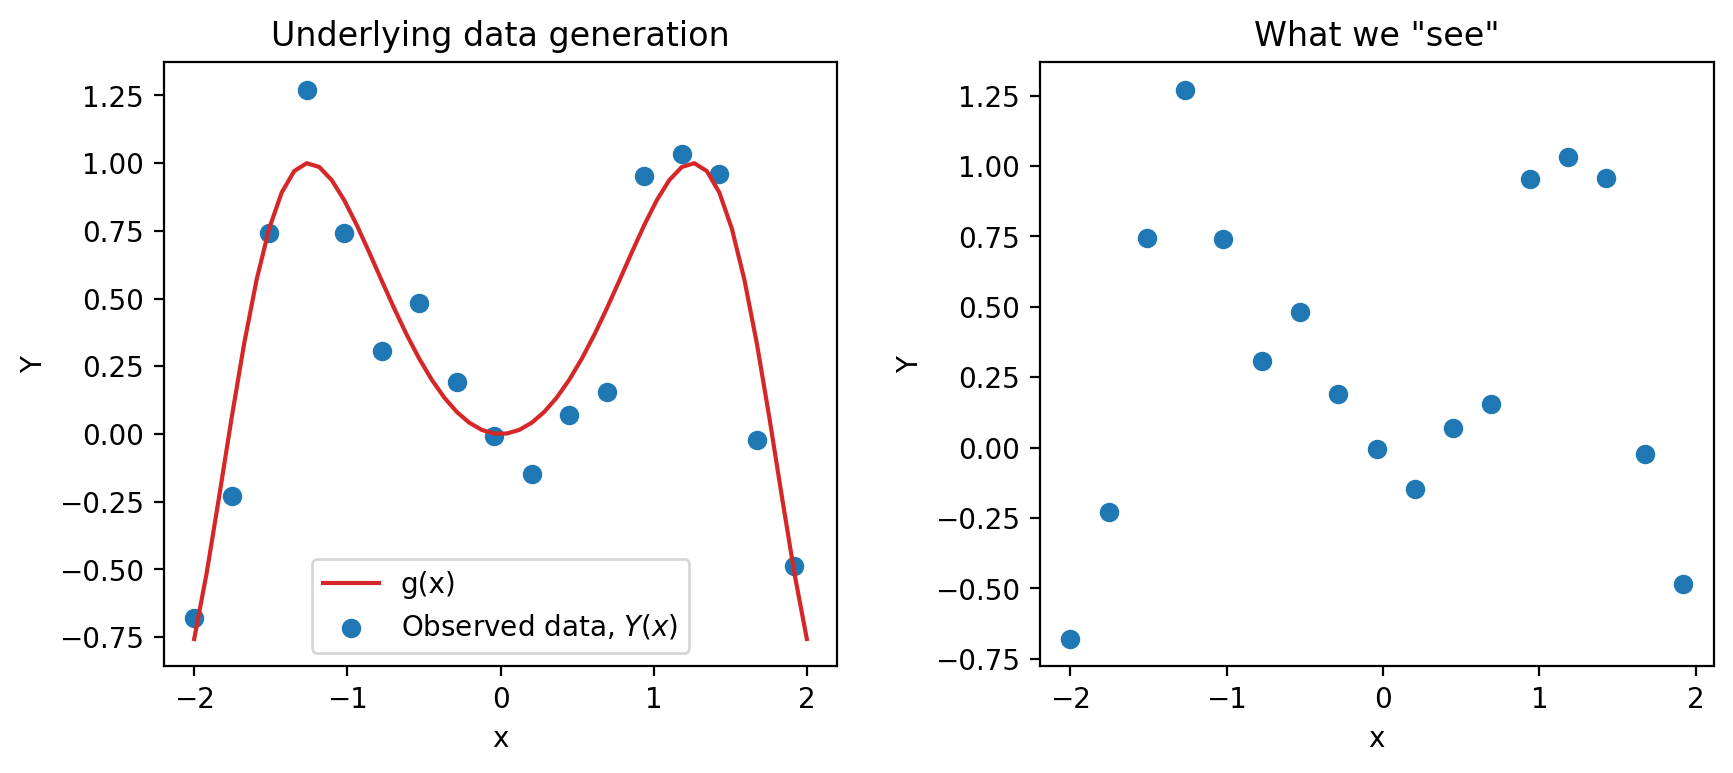

- However, we cannot see the $g(\cdot)$

- We can only see the collected data sample dots

- But the **data collection process always has some inherent error** (e.g. randomness)

	- Each observation comes with **random error / noise $\epsilon$**

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **Assumptions for $\epsilon$**

- $\mathbb{E}[\epsilon]=0$

- $\operatorname{Var}(X)=\sigma^2$

- i.i.d across each observation

</div>

- The existence of random noises means our observation $Y(x)$ are RV

- The data-generating process is $Y(x)=g(x)+\epsilon$

- This can be seen on our graph because the points do not line perfectly with the true underlying relationship, and the residual is the noise

- We only have **IID random sample of data** (Blue dots)

- We need to use them to estimator the true relation $g$

- We do this by training a model on the data to obtain the optimal $\hat{\theta}$

$$\hat{\theta}
=
\arg\min_{\theta}
\left(
\frac{1}{n}
\sum_{i=1}^{n}
\operatorname{Loss}\left(Y_i, f_{\theta}(X_i)\right)
\right)
+
\lambda \operatorname{Regularizer}(\theta)$$

- Once we get the $\hat{\theta}$, we can get $\hat{f} = f_{\hat{\theta}}$ and predict $Y$ as $\hat{Y}$ at a given $x$ location

$$\hat{Y}(x) = \hat{f}(x)$$

- This can be used to estimate $g$

- Then we can compute the errors

$$\left(Y - \hat{Y}(x)\right)^2$$

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- $X_i$, $Y_i$, $\hat{\theta}$, $\hat{Y}(x)$ are all RVs

$$\text{True relationship: } g(x)$$

$$\text{Observed relationship: } Y = g(x) + \epsilon$$

$$\text{Prediction: } \hat{Y}(x) = \hat{f}(x)$$

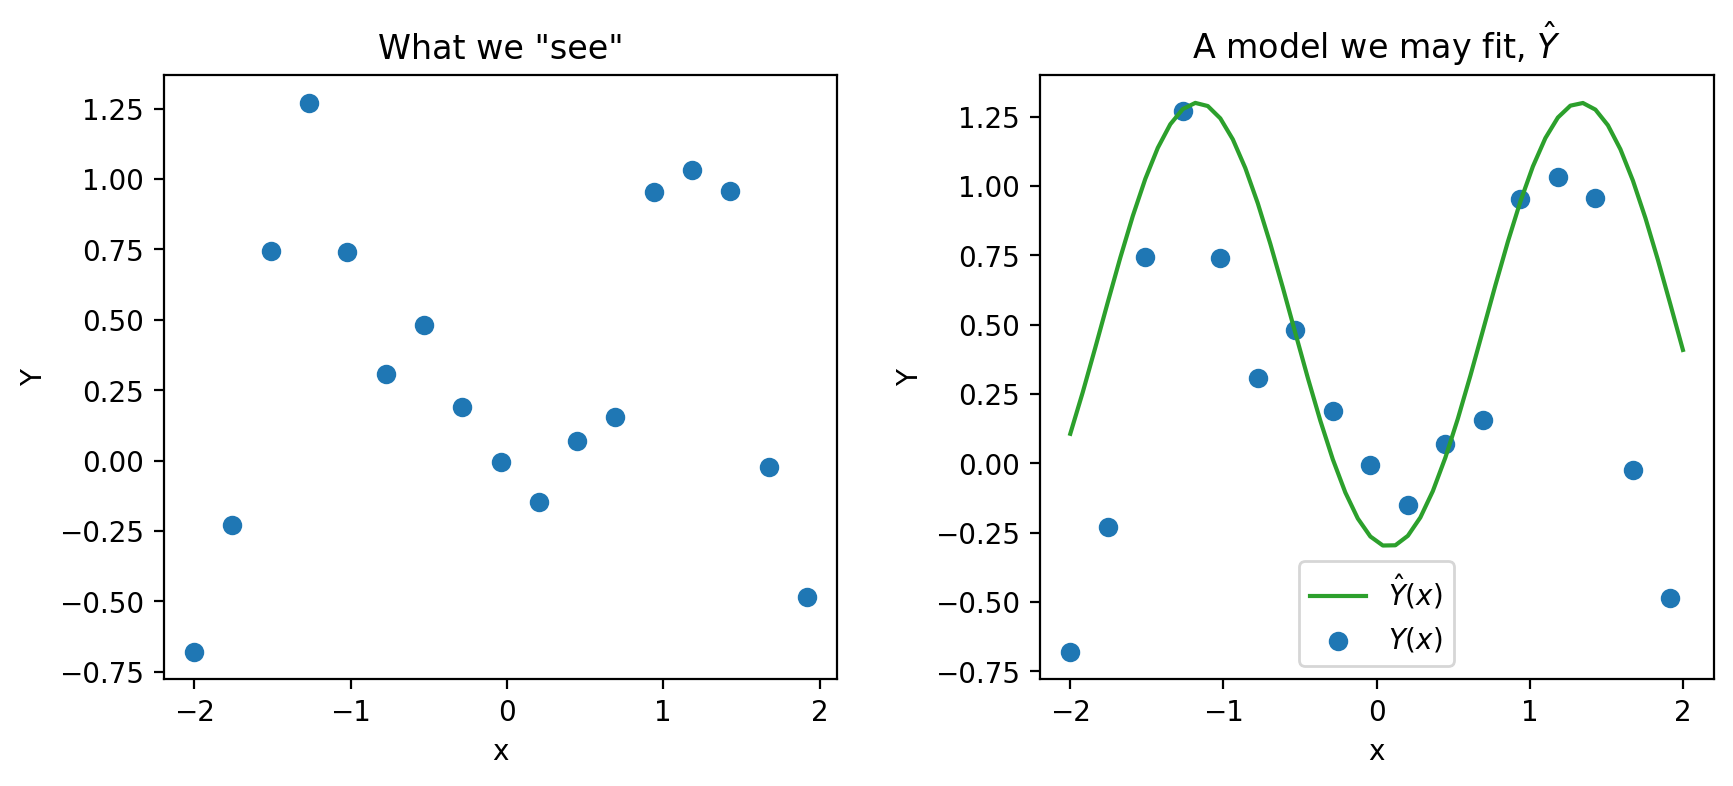

</div>

- When building models, our choice of features will significantly affect our estimation

- Different models (green and purple) can lead to different estimates

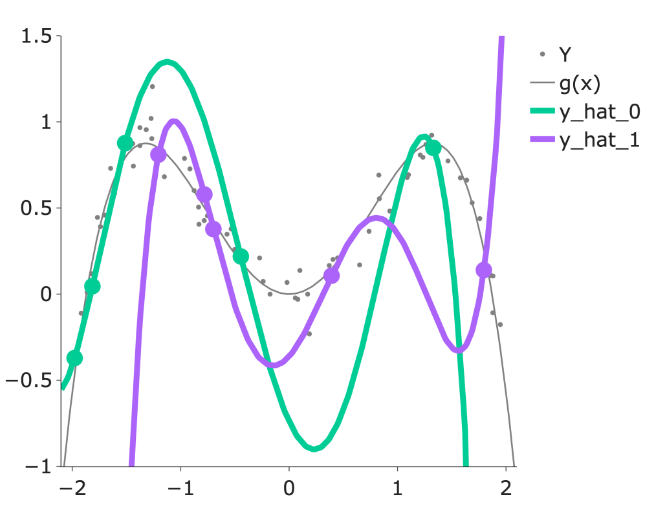

### Model Complexity

- The **bias & variance** of a model is largely **determined by its complexity**

  - **Low complexity**: high bias & low variance (when changing samples)

![alt text](https://ds100.org/course-notes/build/model_simple-d26d7044c6e850683ac8d392f6262400.gif)

  - **High complexity**: low bias & high variance (when changing samples)

![alt text](https://ds100.org/course-notes/build/model_complex-31984ba4de3a48f343d024583486c14b.gif)

## Bias-Variance Tradeoff

### For Estimators

- We want to know how "good" an estimator is:
	
	- Do we get the right answer for the parameter on average? **(Bias)**

	$$\mathrm{Bias}(\hat{\theta}) = E[\hat{\theta} - \theta] = E[\hat{\theta}] - \theta$$

	- How variable is the answer? **(Variance)**

	$$\mathrm{Var}(\hat{\theta}) = E\left[(\hat{\theta} - E[\hat{\theta}])^2\right]$$

- We combine those 2 requirements into a unified metric

	- How close is our estimator to the parameter? **(Risk / MSE)**

	$$\mathrm{MSE}(\hat{\theta}) = E\left[(\hat{\theta} - \theta)^2\right]$$
	
	$$\mathrm{MSE}(\hat{\theta}) = Bias^2 + Variance


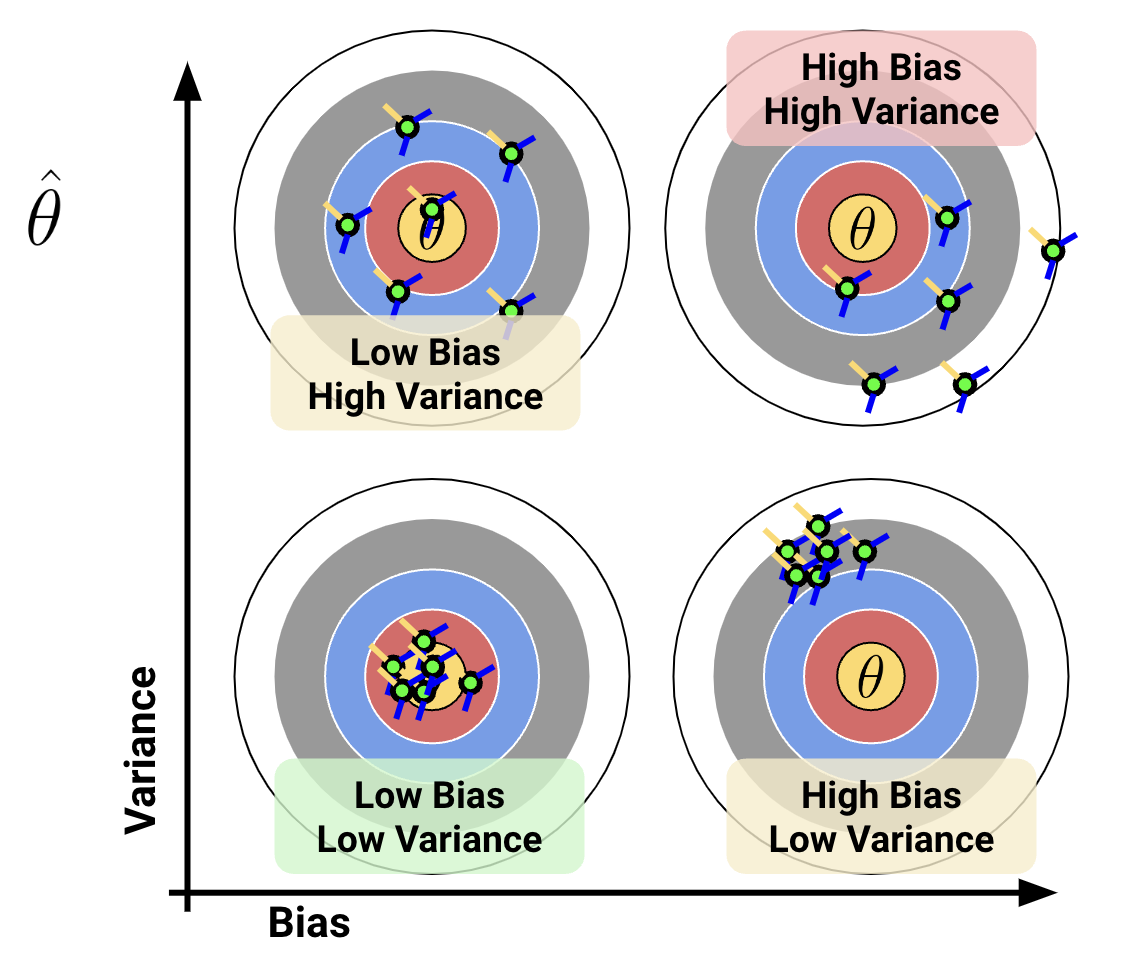

### For Models

- Recall that $\hat{Y}=\hat{f}=f_{\hat{\theta}}$, the estimator will determine the model

- So we can use the same logic to evaluate a **model's quality**

**Model Bias**: How close is our fitted model to $g$ on average?

$$\operatorname{Bias}(f(x)) = \mathbb{E}[f(x)] - g(x)$$

**Model Variance**: How much does our fitted model vary across random samples?

$$\operatorname{Var}(f(x))
= \mathbb{E}\left[\left(f(x)-\mathbb{E}[f(x)]\right)^2\right]$$

- And also combine them together:

**Model risk (MSE)**: What’s the typical squared error between our model’s predictions and the actual outcomes?

$$\mathbb{E}\left[(Y-\hat{Y})^2\right]$$

#### Decomposition of the Model Risk

$$\mathbb{E}\left[(Y-\hat{Y})^2\right]
=
\sigma^2
+
\operatorname{Var}\left(f(\vec{X})\right)
+
\operatorname{Bias}\left(f(\vec{X})\right)^2$$

$$\text{Model Risk}
=
\text{Irreducible error}
+
\text{Model Variance}
+
(\text{Model Bias})^2$$

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **Proof**
Since

$$\operatorname{Var}(Y-\hat{Y})
=
\mathbb{E}\left[(Y-\hat{Y})^2\right]
-
\left(\mathbb{E}[Y-\hat{Y}]\right)^2$$

So

$$\mathbb{E}\left[(Y-\hat{Y})^2\right]
=
\operatorname{Var}(Y-\hat{Y})
+
\left(\mathbb{E}[Y-\hat{Y}]\right)^2$$

First term

$$\begin{aligned}
\operatorname{Var}(Y-\hat{Y})
&= \operatorname{Var}\left(g(\vec{X})+\epsilon-f(\vec{X})\right) \\
&= \operatorname{Var}\left(\epsilon-f(\vec{X})\right) \\
&= \operatorname{Var}(\epsilon)+\operatorname{Var}\left(f(\vec{X})\right) \\
&= \sigma^2+\operatorname{Var}\left(f(\vec{X})\right)
\end{aligned}$$

Second term

$$\begin{aligned}
\left(\mathbb{E}[Y-\hat{Y}]\right)^2
&= \left(\mathbb{E}[Y]-\mathbb{E}[\hat{Y}]\right)^2 \\
&= \left(\mathbb{E}[g(\vec{X})+\epsilon]-\mathbb{E}[f(\vec{X})]\right)^2 \\
&= \left(\mathbb{E}[g(\vec{X})]+\mathbb{E}[\epsilon]-\mathbb{E}[f(\vec{X})]\right)^2 \\
&= \left(g(X)+0-\mathbb{E}[f(\vec{X})]\right)^2 \\
&= \operatorname{Bias}\left(f(\vec{X})\right)^2
\end{aligned}$$

</div>

- **Irreducible error / observational variance / noise** cannot be addressed by modeling. It is inherent in the noise $\epsilon$

**Bias-Variance Tradeoff**

- To **decrease model bias**, we **increase model complexity**. As a result, the model will have **higher model variance**

	- **High variance corresponds to overfitting**

- To **decrease model variance**, we **decrease model complexity**. The model may underfit the sample data and may have **higher model bias**

	- **High bias corresponds to underfitting**

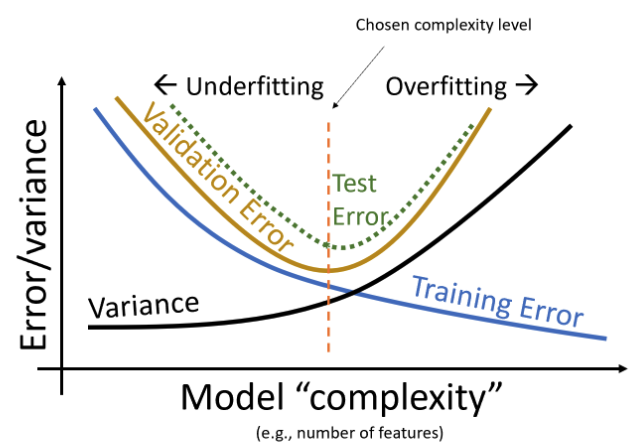

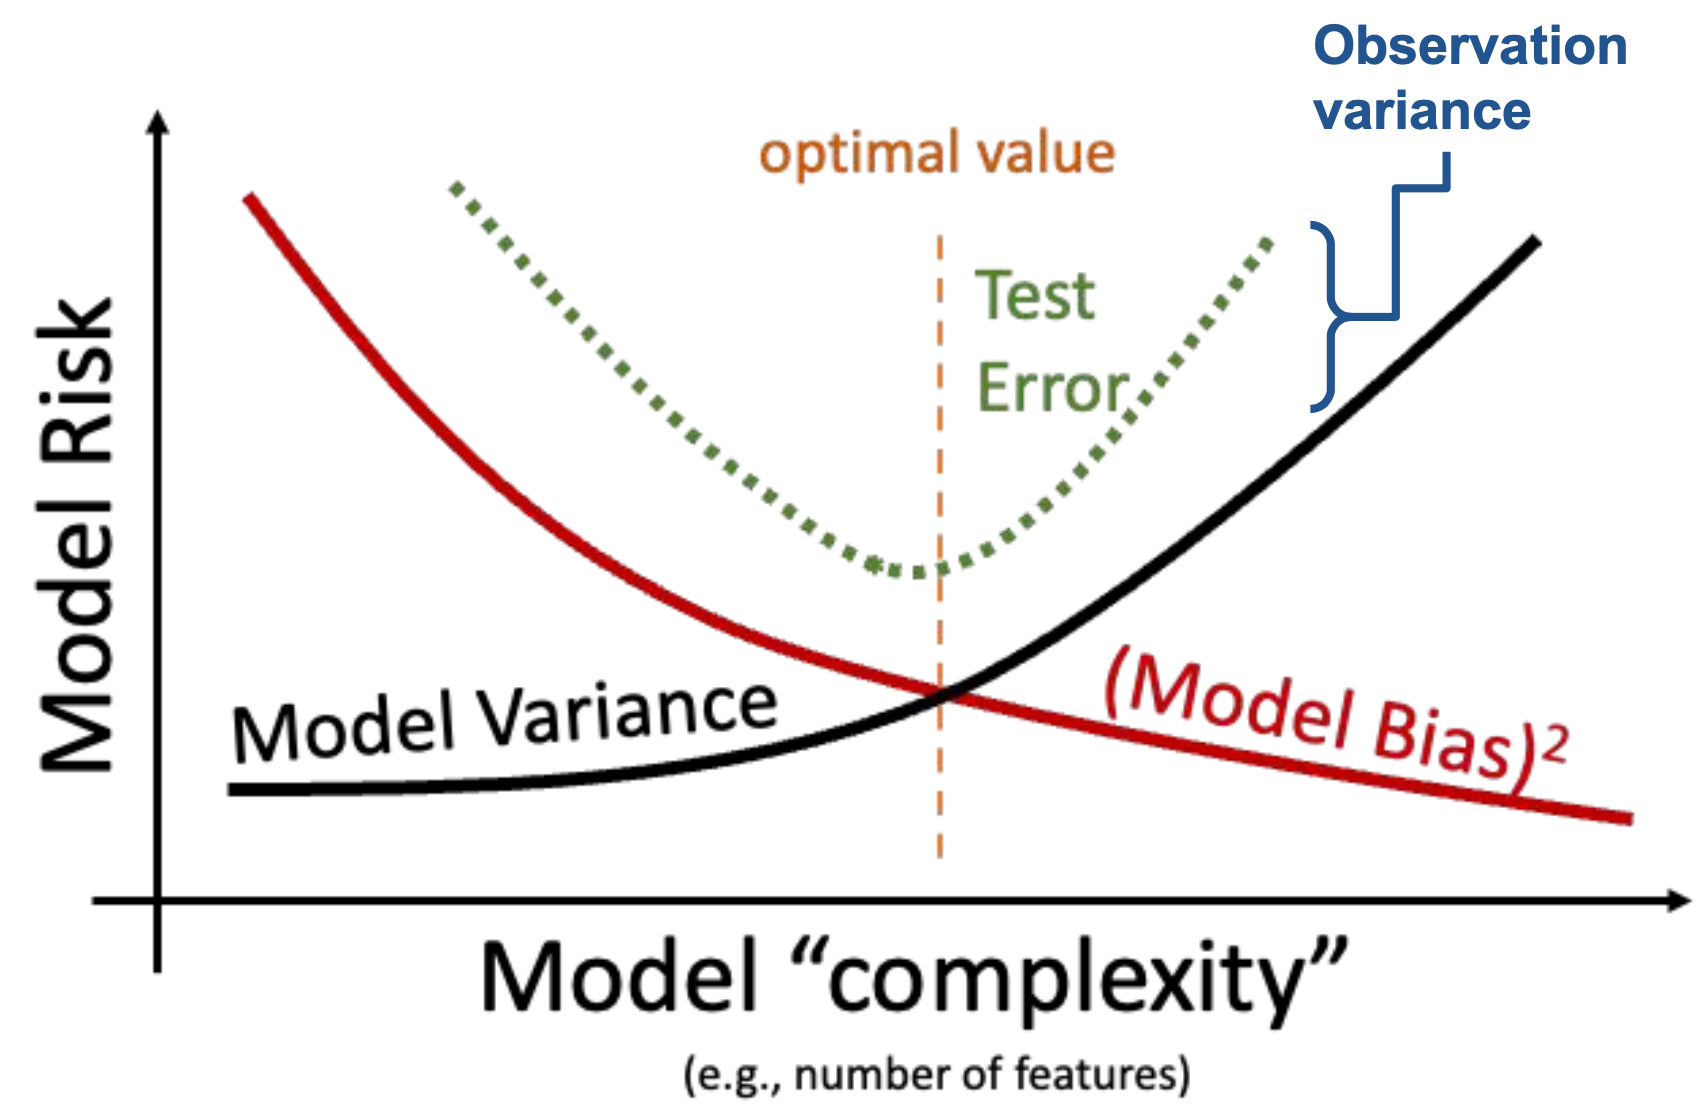

---
[Reference](https://ds100.org/course-notes/probability-2/#sec-bias-variance-tradeoff)